In [1]:
# Setup matplotlib to plot inline (within the notebook)
###
%matplotlib inline
# Import the pyplot module of Matplotlib as plt
###
import matplotlib.pyplot as plt
# Import pandas under the abbreviation 'pd'
###
import pandas as pd
# Import NumPy under the abbreviation 'np'
###
import numpy as np

In [6]:
titanic = pd.read_csv("train.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


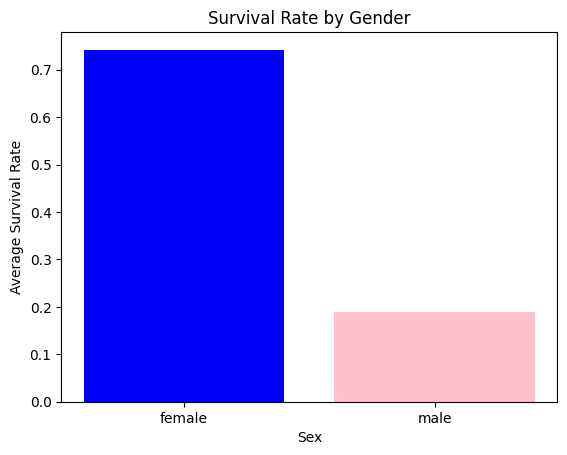

In [ ]:


gender_mean = titanic.groupby('Sex')['Survived'].mean()

# Plot the grouped data
plt.bar(gender_mean.index, gender_mean.values, color=['blue', 'pink'])
plt.xlabel("Sex")
plt.ylabel("Average Survival Rate")
plt.title("Survival Rate by Gender")
plt.show()


In [60]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    object  
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     889 non-null    object  
 11  Title        891 non-null    object  
 12  AgeGroup     891 non-null    category
 13  CabinDeck    891 non-null    object  
dtypes: category(1), float64(2), int64(5), object(6)
memory usage: 91.7+ KB


In [122]:
titanic.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Title          0
AgeGroup       0
CabinDeck      0
dtype: int64

In [123]:
titanic['Age'].fillna(titanic['Age'].median(), inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_4976\2184073557.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['Age'].fillna(titanic['Age'].median(), inplace=True)


In [124]:
titanic.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Title          0
AgeGroup       0
CabinDeck      0
dtype: int64

In [49]:
titanic["Title"] = titanic["Name"].str.extract(' ([A-Za-z]+)\.', expand=False)

# Combine rare titles into one category
rare_titles = ["Dr", "Rev", "Col", "Major", "Mlle", "Countess", "Ms", "Lady", "Jonkheer", "Don", "Dona", "Mme", "Capt", "Sir"]
titanic["Title"] = titanic["Title"].replace(rare_titles, "Rare")

# Normalize similar titles
titanic["Title"] = titanic["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

# 2️⃣ Create Age Groups (bins)
bins = [0, 12, 18, 35, 60, 80]
labels = ['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior']
titanic['AgeGroup'] = pd.cut(titanic['Age'], bins=bins, labels=labels)

In [50]:
# Import Pipeline from sklearn's pipeline module
###
from sklearn.pipeline import Pipeline
# Import ColumnTransformer from sklearn's compose module
###
from sklearn.compose import ColumnTransformer
# Import SimpleImputer from sklearn's impute module
###
from sklearn.impute import SimpleImputer
# Import OneHotEncoder from sklearn's preprocessing module
###
from sklearn.preprocessing import OneHotEncoder
# Import train_test_split from sklearn's model_selection module
###
from sklearn.model_selection import train_test_split

In [56]:
titanic.dtypes

PassengerId       int64
Survived          int64
Pclass            int64
Name             object
Sex              object
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked         object
Title            object
AgeGroup       category
CabinDeck        object
dtype: object

In [72]:
# Drop text features if they exist
titanic = titanic.drop(columns=[col for col in ['Name', 'Ticket'] if col in titanic.columns])

# Process 'Cabin' safely if it exists
if 'Cabin' in titanic.columns:
    # Fill missing with 'Unknown'
    titanic['Cabin'] = titanic['Cabin'].fillna('Unknown')

    # Extract deck letter (first letter)
    titanic['CabinDeck'] = titanic['Cabin'].apply(lambda x: 'Unknown' if x == 'Unknown' else str(x)[0])

    # Drop original 'Cabin' after creating CabinDeck
    titanic = titanic.drop(columns=['Cabin'])
else:
    # If not found, create a placeholder feature
    titanic['CabinDeck'] = 'Unknown'

titanic['Embarked'].fillna('Unknown', inplace=True)


C:\Users\user\AppData\Local\Temp\ipykernel_4976\3764265350.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['Embarked'].fillna('Unknown', inplace=True)


In [102]:
categorical_features = ["Sex", "Embarked" , "Title" , "AgeGroup" , "CabinDeck"]
numerical = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

# Create categorical transformer Pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [103]:
# Setup preprocessing steps (fill missing values, then convert to numbers)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
preprocessor = ColumnTransformer(
    transformers=[
        # Use the categorical_transformer to transform the categorical_features
        ("cat", categorical_transformer, categorical_features),
        ('num', StandardScaler(), numerical),
        ])

In [104]:
titanic.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,AgeGroup,CabinDeck
0,1,0,3,male,22.0,1,0,7.2500,S,Mr,YoungAdult,Unknown
1,2,1,1,female,38.0,1,0,71.2833,C,Mrs,Adult,Unknown
2,3,1,3,female,26.0,0,0,7.9250,S,Miss,YoungAdult,Unknown
3,4,1,1,female,35.0,1,0,53.1000,S,Mrs,YoungAdult,Unknown
4,5,0,3,male,35.0,0,0,8.0500,S,Mr,YoungAdult,Unknown


In [76]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Sex          891 non-null    object  
 4   Age          891 non-null    float64 
 5   SibSp        891 non-null    int64   
 6   Parch        891 non-null    int64   
 7   Fare         891 non-null    float64 
 8   Embarked     891 non-null    object  
 9   Title        891 non-null    object  
 10  AgeGroup     891 non-null    category
 11  CabinDeck    891 non-null    object  
dtypes: category(1), float64(2), int64(5), object(4)
memory usage: 77.8+ KB


In [78]:

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# XGBoost model
from xgboost import XGBClassifier

# Model evaluation and splitting
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
regression_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

regression_results = {}

In [88]:
X = titanic.drop("Survived", axis=1)
y = titanic["Survived"]

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=20, random_state=42
)
X_train.shape , X_test.shape , y_train.shape, y_test.shape

((871, 11), (20, 11), (871,), (20,))

Logistic Regression: 0.822 (+/- 0.044)
Random Forest: 0.809 (+/- 0.016)
XGBoost: 0.817 (+/- 0.029)


In [114]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [145]:
from sklearn.model_selection import cross_val_score
for model_name, model in regression_models.items():
    
    # Create a model Pipeline with a preprocessor step and model step
    model_pipeline = Pipeline(steps=[("preprocessor", preprocessor),
                                      ("model", model)])
    
    # Fit the model Pipeline to the car sales training data
    scores = cross_val_score(model_pipeline, X_train, y_train, cv=5)
    print(f"{model_name}: {scores.mean():.3f} (+/- {scores.std():.3f})")
    model_pipeline.fit(X_train, y_train)
    y_pred = model_pipeline.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print()


Logistic Regression: 0.822 (+/- 0.044)
Accuracy: 0.9
Precision: 1.0
Recall: 0.8
F1: 0.8888888888888888
Confusion Matrix:
 [[10  0]
 [ 2  8]]

Random Forest: 0.809 (+/- 0.016)
Accuracy: 0.9
Precision: 1.0
Recall: 0.8
F1: 0.8888888888888888
Confusion Matrix:
 [[10  0]
 [ 2  8]]

XGBoost: 0.817 (+/- 0.029)
Accuracy: 0.9
Precision: 0.9
Recall: 0.9
F1: 0.9
Confusion Matrix:
 [[9 1]
 [1 9]]



In [146]:
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

logreg_pipeline.fit(X_train, y_train)
# Make predictions on the test set
y_pred = logreg_pipeline.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Show confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9
Precision: 1.0
Recall: 0.8
F1 Score: 0.8888888888888888

Confusion Matrix:
[[10  0]
 [ 2  8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        10
           1       1.00      0.80      0.89        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20



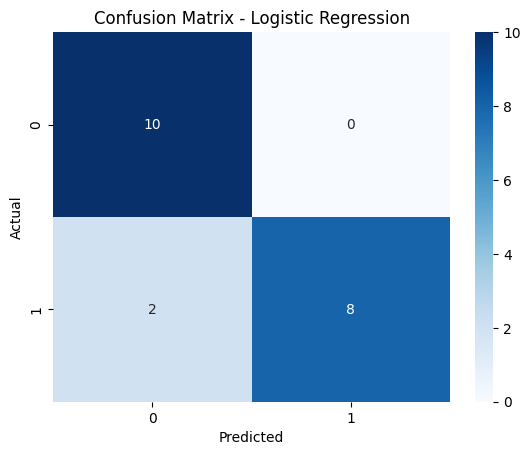

In [147]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
